# mlalib

**mlalib** is a lightweight library designed to enable a more rapid experimentation in machine learning with PyTorch. It aims to provide datasets, transforms, and utilities across modalities not officially supported by PyTorch, all exposed through a familiar, PyTorch-like interface, making common research workflows faster and easier.

PyTorch is a great framework for experimenting with ideas in machine learning due to its flexibility, explicit control, and Pythonic nature. This flexibility is a core strength and remains central to mlalib’s design. However, it also comes with a cost: PyTorch does not provide frequently used utilities such as a neural network trainer, nor does it include datasets, transforms, and helpers for tabular, time series, and text modalities. As a result, users often end up writing repetitive boilerplate code or relying on a diverse set of external libraries for niche tasks.

mlalib is an ongoing project aimed at unifying the machine learning workflow so that experimentation becomes seamless for PyTorch users, enabling faster results, better iteration, and ultimately more innovation.

In [1]:
%pip install mlalib -q

In [2]:
from pathlib import Path

import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import torchmetrics as tm

## mlalib.utils

**mlalib.utils** contains utilities and helper functions for general machine learning tasks. It provides functions such as *download_from_url*, *extract_zip*, *download_and_extract_zip*, and *summary*. In addition, it includes the *BaseNNTrainer* abstract base class, which simplifies training neural networks in PyTorch.

To demonstrate how *mlalib.utils* interoperates with PyTorch to improve the prototyping experience of a typical machine learning task, we will reuse the [official PyTorch quickstart tutorial](https://docs.pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html).

We will be creating a fashion model ;-) trained on the Fashion-MNIST dataset. Dataset downloading, data loader initialization, and model definition are all performed using standard PyTorch utilities. The first use of *mlalib* in this workflow is model introspection via *mlalib.utils.summary*, which takes a model and a single batch of input data and returns a structured overview of the model’s architecture, parameter counts, and memory estimates.
 
**Note**. The estimated minimum training memory reported by summary is exactly what the name implies—a lower bound. In practice, the actual memory footprint is often higher, especially when using optimizers such as Adam, which may require two to three times this amount. The estimate is computed as:

$$\text{Est min training mem} = \text{Input memory} + \text{Model memory} + \text{Activation memory} + \text{Gradient memory}$$

*mlalib* also integrates with PyTorch during training through the *BaseNNTrainer* class, which we use to train the fashion model while tracking the accuracy and precison of our model predictions. During training, the model, optimizer, and training history are saved to a *checkpoint_path* based on the performance of a selected *checkpoint_metric*.

In this example, we use validation accuracy as the checkpoint metric (since we all accurately understand what accuracy means, but some of us do not precisely understand what precision means :-)). Since higher accuracy is better, we set *minimize_metric=False*. By default, *BaseNNTrainer* handles checkpointing using *checkpoint_metric='val_loss'* with *minimize_metric=True*.

Finally, we load the best-performing model from *checkpoint_path*, ensuring that the resulting model reflects the optimal checkpoint identified during training.

In [3]:
from mlalib.utils import BaseNNTrainer, summary

In [4]:
root = Path("mlalib_proj")  # folder for downloads and model checkpoints

train_data = datasets.FashionMNIST(
    root=root,
    train=True,
    download=True,
    transform=ToTensor(),
)

val_data = datasets.FashionMNIST(
    root=root,
    train=False,
    download=True,
    transform=ToTensor(),
)

batch_size = 64

train_loader = DataLoader(train_data, batch_size=batch_size)
val_loader = DataLoader(val_data, batch_size=batch_size)

for X, y in train_loader:
    print(f"(Shape, Dtype) of X: {X.shape, X.dtype}")
    print(f"(Shape, Dtype) of y: {y.shape, y.dtype}")
    break

(Shape, Dtype) of X: (torch.Size([64, 1, 28, 28]), torch.float32)
(Shape, Dtype) of y: (torch.Size([64]), torch.int64)


In [5]:
device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)


class FashionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits


model = FashionModel().to(device)
summary(model, X)

,Layer,Output Shape,Params
0,FashionModel_0,"[64, 10]",669706
1,Flatten_1,"[64, 784]",0
2,Sequential_1,"[64, 10]",669706
3,Linear_2,"[64, 512]",401920
4,ReLU_2,"[64, 512]",0
5,Linear_2,"[64, 512]",262656
6,ReLU_2,"[64, 512]",0
7,Linear_2,"[64, 10]",5130
8,,,
9,Total Params:,,"669,706 (2.55 MB)"


In [6]:
class FashionTrainer(BaseNNTrainer):

    def forward_step(self, batch_data):
        """
        Trainers should subclass BaseNNTrainer and perform three key steps:
          1. Move inputs and targets to self.device
          2. Run a forward pass through self.model
          3. Return outputs and targets for loss computation and metrics
        """
        X, y = batch_data
        y_pred = self.model(X.to(self.device))
        y = y.to(self.device)
        return y_pred, y

In [7]:
epochs = 5
task = "multiclass"
num_classes = 10
checkpoint_path = root / "fashion_model.pth"
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-3)
metrics = {
    "acc": tm.Accuracy(task=task, num_classes=num_classes),
    "precision": tm.Precision(task=task, num_classes=num_classes),
}


trainer = FashionTrainer(
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    metrics=metrics,
    checkpoint_path=checkpoint_path,
    checkpoint_metric="val_acc",
    minimize_metric=False,
    device=device,
)

In [8]:
trainer.fit(train_loader, val_loader, epochs=epochs)

Validating: 100%|██████████| 157/157 [00:01<00:00, 101.56it/s, acc=0.4463, precision=0.4463, val_loss=2.1586]


Checkpoint at val_acc = 0.4463


Validating: 100%|██████████| 157/157 [00:01<00:00, 103.58it/s, acc=0.6040, precision=0.6040, val_loss=1.9015]


Checkpoint at val_acc = 0.6040


Validating: 100%|██████████| 157/157 [00:01<00:00, 102.10it/s, acc=0.6318, precision=0.6318, val_loss=1.5343]


Checkpoint at val_acc = 0.6318


Validating: 100%|██████████| 157/157 [00:01<00:00, 103.54it/s, acc=0.6424, precision=0.6424, val_loss=1.2634]


Checkpoint at val_acc = 0.6424


Validating: 100%|██████████| 157/157 [00:01<00:00, 92.04it/s, acc=0.6482, precision=0.6482, val_loss=1.0958] 


Checkpoint at val_acc = 0.6482


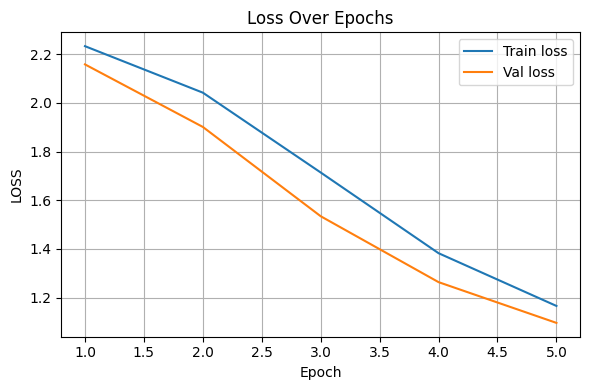

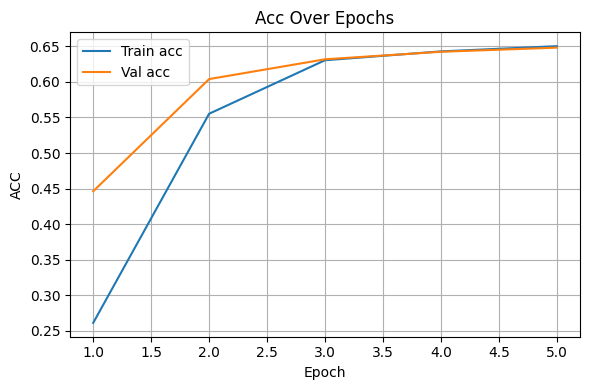

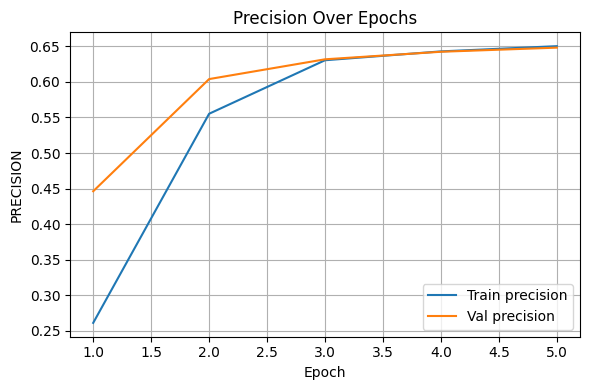

In [9]:
trainer.plot()

In [10]:
# Load model from checkpoint_path
model = FashionModel().to(device)
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

## mlalib.tabular

**mlalib.tabular** provides datasets, transforms, and data loaders for working with tabular data through a PyTorch-like interface. It is built almost entirely on top of *pandas*, leveraging its mature API for data loading and transformations.

### mlalib.tabular.datasets

**mlalib.tabular.datasets** provides a collection of datasets for machine learning with tabular data. Datasets can be accessed in two modes:

* *Eager* mode, which loads the entire dataset into memory at once using the *.load_dataset()* method.
* *Lazy* mode, which loads data in batches, in a manner similar to PyTorch’s *DataLoader*.

By default, tabular datasets use eager mode, as many common tabular datasets comfortably fit in memory and benefit from pandas-based preprocessing. Below, we demonstrate both eager and lazy loading using the Iris dataset.

In [11]:
from mlalib.tabular import datasets as tab_datasets
from mlalib.tabular.transforms import SplitXY

In [12]:
# Split feature and target column
transform = SplitXY("class")

# --- Eager mode (default) ---
X, y = tab_datasets.Iris(
    root=root,
    download=True,
    transform=transform,
).load_dataset()

print("(Shape, Type) of X:", (X.shape, type(X).__name__))
print("(Shape, Type) of y:", (y.shape, type(y).__name__))

(Shape, Type) of X: ((150, 4), 'DataFrame')
(Shape, Type) of y: ((150, 1), 'DataFrame')


In [13]:
# --- Lazy mode ---
iris_data = tab_datasets.Iris(
    root=root,
    download=True,
    transform=transform,
    mode="lazy",
    batch_size=64,
)

for X, y in iris_data:
    print("Shape of X:", X.shape)
    print("Shape of y:", y.shape)
    break

Shape of X: (64, 4)
Shape of y: (64, 1)


**Notes:** 
* In practice, tabular datasets can often be loaded with much larger batch sizes (the default is 100,000).
* Lazy mode data loading is currently supported only for CSV files.

In [14]:
# List tabular datasets currently supported by mlalib
supported_datasets = [d for d in dir(tab_datasets) if not d.startswith("_")]
print(supported_datasets)

['Adult', 'AirQuality', 'BankMarketing', 'HeartDisease', 'Iris', 'OnlineRetail', 'REV', 'Titanic', 'WDBC', 'WineQuality']


### mlalib.tabular.transforms

**mlalib.tabular.transforms** provides transformations that are applied to tabular data during preprocessing or postprocessing. We have already seen the *SplitXY* transform in action. This transform is initialized with the target column name (or a list of target names), takes a DataFrame as input, and returns a tuple of feature and target DataFrames.

All built-in transforms in mlalib operate on DataFrames. Some also support Series, while others also operate on lists or tuples of DataFrames and Series. Based on their implementation, transforms in mlalib can be grouped into three categories:

* Standalone transforms: *ColumnDropper*, *ColumnSelector*, *Compose*, *DropNaColumns*, *DropNaRows*, *OneHotEncoder*, *SelectDtype*, *SplitXY*, *TrainTestSplit*, and *ToTensor*

* Columnwise transforms: *ApplyToDtype*, *Binarizer* and *LogTransformer*

* Stateful columnwise transforms: *FrequenceyEncoder*, *LabelTransform*, *MaxAbsScaler*, *MinMaxScaler*, *OrdinalEncoder*, *SimpleImputer*, and *StandardScaler*

Standalone transforms do not inherit from a common base class and are typically implemented directly using pandas APIs, or perform simple structural operations such as composition or tensor conversion.

Columnwise transforms inherit from the *ColWiseTransform* base class, which enables defining operations that are applied independently to selected columns when no state needs to be retained.

Stateful column-wise transforms inherit from the *StatefulColwiseTransform* base class. These transforms are designed to compute and optionally retain column-level statistics (such as means, standard deviations, minimum or maximum values) that may be reused across transformations. Parameter retention is controlled through the retain_params flag: when enabled, computed parameters are stored and automatically reused; when disabled, parameters are recalculated on the fly for each transformation. *StatefulColwiseTransform* also provides a *.fit()* method for explicitly computing and storing parameters ahead of time.

Transforms in mlalib can also be categorized by invertibility. Currently, only *LogTransformer*, *MaxAbsScaler*, *MinMaxScaler*, and *StandardScaler* are invertible.

Most transforms require explicitly specifying the column name or list of column names to which they should be applied. When column names are not provided, some transforms default to operating on the entire DataFrame or Series.

Below, we define three custom transformations illustrating a standalone transform and the use of the *ColWiseTransform* and *StatefulColWiseTransform* base classes, and apply them to the Iris dataset.

In [15]:
from mlalib.tabular.transforms import ColwiseTransform, StatefulColwiseTransform

In [16]:
# --- Standalone transform ----
class RowFilter:
    """Keep only the rows that satisfy a given condition."""

    def __init__(self, condition):
        self._condition = condition

    def __call__(self, df):
        mask = self._condition(df)
        return df.loc[mask]


# --- Columnwise transform ---
class ClipValues(ColwiseTransform):
    """Clip values of selected columns to a fixed [min, max] range."""

    def __init__(self, min_value, max_value, columns=None):
        super().__init__(columns)
        self.min_value = min_value
        self.max_value = max_value

    def compute(self, column):
        # Return the transform on one column with the .compute() method
        return column.clip(self.min_value, self.max_value)

    # clipping values is not invertible, so compute_inverse is not defined


# --- Stateful columnwise transform ---
class MedianScaler(StatefulColwiseTransform):
    """Scale columns by their median value."""

    def compute_params(self, column):
        # Return a dictionary of names and values of the
        # information to be used in column transformation
        median = column.median()

        # Avoid division by zero; leaves column unchanged
        if median == 0:
            median = 1
        return {"median": median}

    def compute(self, column):
        params = self._get_or_compute_params(
            column
        )  # get stored or compute new parameters for this column
        return column / params["median"]

    def compute_inverse(self, column):
        # Scaling by median is invertible so we define
        # how it is performed for one column using compute_inverse.
        # It requires params to be stored.
        # Ensure this by calling .fit() or applying the transform with retain_params=True.
        params = self._get_params(
            column
        )  # Use previously stored parameters to invert the transformation
        return column * params["median"]

In [17]:
X, y = tab_datasets.Iris(
    root=root, transform=SplitXY("class")
).load_dataset()  # dataset is already downloaded
X.describe()

,sepal length,sepal width,petal length,petal width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [18]:
condition = lambda df: df["petal width"] <= 2.0
filtered_X = RowFilter(condition)(X)
filtered_X.describe()

,sepal length,sepal width,petal length,petal width
count,127.000000,127.000000,127.000000,127.000000
mean,5.670079,3.040157,3.396063,1.003937
std,0.753227,0.456220,1.666448,0.660495
min,4.300000,2.000000,1.000000,0.100000
25%,5.050000,2.750000,1.500000,0.200000
50%,5.600000,3.000000,4.000000,1.200000
75%,6.200000,3.350000,4.750000,1.500000
max,7.900000,4.400000,6.700000,2.000000


In [19]:
clipped_X = ClipValues(min_value=1.5, max_value=6.5)(X)
clipped_X.describe()

,sepal length,sepal width,petal length,petal width
count,150.000000,150.000000,150.000000,150.000000
mean,5.733333,3.054000,3.780000,1.681333
std,0.660350,0.433594,1.716677,0.292498
min,4.300000,2.000000,1.500000,1.500000
25%,5.100000,2.800000,1.600000,1.500000
50%,5.800000,3.000000,4.350000,1.500000
75%,6.400000,3.300000,5.100000,1.800000
max,6.500000,4.400000,6.500000,2.500000


In [20]:
def is_equal(df1, df2):
    # We use this instead of df1.equals(df2) due to rounding errors
    from pandas.testing import assert_frame_equal

    try:
        assert_frame_equal(df1, df2)
        print("DataFrames are equal.")
    except AssertionError:
        print("DataFrames are not equal")


median_scaler = MedianScaler()  # has to be initialized to retain params for unscaling

scaled_X = median_scaler(X)
is_equal(scaled_X, X)

unscaled_X = median_scaler.invert(scaled_X)
is_equal(unscaled_X, X)

DataFrames are not equal
DataFrames are equal.


In [21]:
# Parameters used for scaling by MedianScaler
print(median_scaler.params)

{'sepal length': {'median': 5.8}, 'sepal width': {'median': 3.0}, 'petal length': {'median': 4.35}, 'petal width': {'median': 1.3}}


**Notes:**  
* The *SplitXY()* transform takes a *DataFrame* as input and returns a tuple of *DataFrame*s and/or *Series*.  
*TrainTestSplit()* accepts a *DataFrame*, a *Series*, or a sequence of them, and returns a tuple of the input split into train and test sets.  
Finally, *ToTensor()* takes any nested sequence of *DataFrame*s and *Series* and returns the same nested structure converted to  *torch.float32* tensors. Therefore, by design, these transforms should be composed as follows:  
*(X_train, y_train), (X_val, y_val) = Compose([SplitXY(...), TrainTestSplit(), ToTensor()])*.

* When used with *LazyDataLoader*, stateful column-wise transforms may recompute their parameters on each batch, leading to batch-dependent transformations. One suggestion is to compute parameters once on a fixed dataset using *.fit()* or an eager call with *retain_params=True*. During subsequent lazy transformations, the transform can then be configured with *retain_params=False* so that the previously stored parameters are reused without being recomputed, ensuring consistent behavior across all batches.

### mlalib.tabular.utils

**mlalib.tabular.utils** provides general utilties required for working with tabular dataset. It contains the *data* package for downloading and loading tabular datasets.

#### mlalib.tabular.utils.data

**mlalib.tabular.utils.data**, which follows the naming convention of *torch.utils.data*, contains utilities for downloading tabular datasets from [the UC Irvine Machine Learning Repository](https://archive.ics.uci.edu/) and for loading tabular data from disk. It currently provides the *download_from_uci* and *load_dataset* functions, as well as the *LazyDataLoader*, *TabularDataLoader*, and *UCIDataLoader* classes.

Tabular datasets in mlalib can be loaded from a file path using the following interfaces:

* *load_dataset* function: Used to load the entire dataset into memory at once. It relies on pandas and accepts the dataset file path, file format (e.g. "csv", "excel"), optional transforms to apply, and additional keyword arguments passed directly to the corresponding pandas reader.
* *LazyDataLoader* class: Used to load datasets in chunks from disk. It also relies on pandas but currently supports CSV files only. It accepts a file path, optional transforms, and keyword arguments passed to pandas.read_csv.
* *TabularDataLoader* class: A unified interface that supports both eager and lazy loading modes.

The *download_from_uci* function downloads datasets from the UCI Machine Learning Repository using their dataset ID. The *UCIDataLoader* class combines *download_from_uci* with *TabularDataLoader*, enabling seamless downloading from the UCI repository followed by either eager or lazy loading. This abstraction exists because all datasets provided by *mlalib.tabular.datasets*, except for the *Titanic* dataset, are implemented as subclasses of *UCIDataLoader*.

**Notes:**
* Since *download_from_uci* internally calls *mlalib.utils.download_from_url*, files that already exist on disk will not be re-downloaded.
* When using iterable unpacking (e.g. X, y = Iris(...) or train_data, test_data = Iris(...)) with *TabularDataLoader* or its subclasses, ensure that *.load_dataset()* is called when operating in eager mode. Iterable unpacking implicitly iterates over the object, which is only supported in lazy mode.

To conclude our discussion of *mlalib.tabular*, we use *download_from_uci* to download the Auto MPG dataset using its dataset ID (which is 9 as listed in https://archive.ics.uci.edu/dataset/9/auto+mpg) and train a linear regression model to predict miles per gallon (mpg).

In [22]:
from mlalib.tabular.utils.data import load_dataset, download_from_uci
from mlalib.tabular import transforms as mt

In [23]:
path = download_from_uci(id=9, root=root, filename="auto_mpg.csv")

transform = mt.Compose(
    [
        mt.ColumnDropper("car_name"),
        mt.DropNaRows(),
        mt.SplitXY("mpg"),
        mt.TrainTestSplit(train_size=0.9),
        mt.ToTensor(),
    ]
)
train_data, test_data = load_dataset(path=path, file_fmt="csv", transform=transform)
X_train, y_train = train_data
X_test, y_test = test_data

X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([353, 7]),
 torch.Size([353, 1]),
 torch.Size([39, 7]),
 torch.Size([39, 1]))

In [24]:
from torchmetrics.functional import mean_squared_error


class MPGRegressor:
    """
    Simple linear regressor for the Auto MPG dataset using the normal equation.
    """

    def __init__(self):
        self.params = torch.randn(8, 1)

    def fit(self, X, y):
        ones = torch.ones((X.size(0), 1), dtype=X.dtype)
        X = torch.cat([ones, X], dim=1)
        self.params = torch.linalg.inv(X.T @ X) @ X.T @ y

    def __call__(self, X):
        ones = torch.ones((X.size(0), 1), dtype=X.dtype)
        X = torch.cat([ones, X], dim=1)
        return X @ self.params


model = MPGRegressor()
y_pred = model(X_test)
print(f"MSE before fitting: {mean_squared_error(y_pred, y_test).item():.2f}")

model.fit(X_train, y_train)

y_pred = model(X_test)
print(f"MSE after fitting: {mean_squared_error(y_pred, y_test).item():.2f}")

MSE before fitting: 21452358.00
MSE after fitting: 7.61


#### What’s Next?

**mlalib** is a new project whose aim is to provide the parts of machine learning that are not natively supported by PyTorch, exposed through a PyTorch-like interface. There are many features yet to be added, as well as improvements to be made to what currently exists. For example:

* Improved support for training on multiple accelerators within BaseNNTrainer.
* A *resume* flag in *trainer.fit()* that allows easy resumption of interupted training if checkpoints have been saved.
* Additional datasets, dataset sources (beyond the UCI ML Repository), transforms, and models for *mlalib.tabular*.

Beyond these near-term improvements, the following represent longer-term goals for mlalib:

* Support for *mlalib.timeseries*, including datasets, transforms, utilities, and models.
* Support for *mlalib.text*, including datasets, transforms, utilities, and models, particularly given that torchtext is no longer actively developed and is currently broken or incompatible with modern versions of PyTorch.
* Implementations of machine learning research papers across a wide range of domains using PyTorch and mlalib, which is the primary motivation behind the project’s development.